In [1]:
import tensorflow as tf
print(tf.__version__)

2.21.0


In [2]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Activation

model=Sequential()
model.add(Dense(64, input_shape=(10,)))
model.add(Activation('relu'))

model.summary()

c:\Users\hp\OneDrive\Desktop\AI Internship\srmccem\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 64)             │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 704 (2.75 KB)

 Trainable params: 704 (2.75 KB)

 Non-trainable params: 0 (0.00 B)

In [3]:
import pandas as pd

data = pd.read_csv('../wine.csv')
y = data['quality']
x = data.drop('quality', axis=1)

from modulefinder import test
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.25, random_state=42)


In [4]:
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(1199, 11)
(400, 11)
(1199,)
(400,)


In [5]:
from sklearn.neural_network import MLPClassifier
model=MLPClassifier(hidden_layer_sizes=(64,32), activation='tanh',max_iter=5)
model.fit(x_train,y_train)
print(model.score(x_test,y_test))

0.48


c:\Users\hp\OneDrive\Desktop\AI Internship\srmccem\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (5) reached and the optimization hasn't converged yet.
  warnings.warn(


In [6]:
from sklearn.metrics import classification_report, confusion_matrix
y_pred = model.predict(x_test)
confusion_matrix = confusion_matrix(y_test, y_pred)
print(confusion_matrix)

[[  0   0   0   1   0   0]
 [  0   0   4   9   0   0]
 [  0   0 103  61   0   0]
 [  0   0  80  89   0   0]
 [  0   0  15  33   0   0]
 [  0   0   1   4   0   0]]


In [7]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model = Sequential()
model.add(Dense(64, input_dim=10, activation='relu'))   
model.add(Dense (6, activation='relu'))
model.summary()


c:\Users\hp\OneDrive\Desktop\AI Internship\srmccem\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 64)             │           704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,094 (4.27 KB)

 Trainable params: 1,094 (4.27 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model = Sequential()
model.add(Dense(64, activation='relu', input_dim=x_train.shape[1]))
model.add(Dense(6, activation='softmax'))
model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 64)             │           768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,158 (4.52 KB)

 Trainable params: 1,158 (4.52 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:

import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
model = Sequential()
model.add(Dense(64, input_shape=(x_train.shape[1],), activation='relu'))
model.add(Dense(6, activation='softmax'))
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
y_train_encoded = y_train - 3  # Adjusting labels to start from 0
model.fit(x_train, y_train_encoded, epochs=20, batch_size=32, validation_split=0.2)

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.4056 - loss: 1.9191 - val_accuracy: 0.4875 - val_loss: 1.3225
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4536 - loss: 1.3834 - val_accuracy: 0.5000 - val_loss: 1.1756
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4838 - loss: 1.2466 - val_accuracy: 0.5208 - val_loss: 1.1321
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4922 - loss: 1.1986 - val_accuracy: 0.5500 - val_loss: 1.1104
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4943 - loss: 1.1651 - val_accuracy: 0.5292 - val_loss: 1.0939
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5130 - loss: 1.1454 - val_accuracy: 0.4958 - val_loss: 1.0837
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5099 - loss: 1.1344 - val_accuracy: 0.5375 - val_loss: 1.0654
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5099 - loss: 1.1298 - val_accuracy: 0.5417 - val_loss:

In [10]:
print(np.unique(y_train_encoded))  # Check the unique values in the adjusted labels

[0 1 2 3 4 5]


In [11]:
pred=model.predict(x_test)
pred=np.argmax(pred, axis=1) 
pred=pred+3
print(pred)

model.save('wine_quality_model.h5')
print("Model Save Successfully")

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


[5 5 6 6 6 5 5 6 6 6 6 6 6 6 6 6 5 5 6 5 5 5 6 6 6 6 5 5 5 5 5 5 6 6 6 5 6
 6 5 6 5 5 6 5 6 6 6 5 5 6 5 5 6 5 5 5 6 5 6 6 5 6 6 5 6 6 6 5 6 5 6 5 6 6
 6 5 6 5 5 6 5 6 5 6 6 6 5 6 5 6 6 5 6 6 5 6 5 6 5 6 6 6 6 6 6 6 6 5 5 5 6
 5 6 5 6 6 6 5 5 6 6 5 6 5 6 6 6 5 5 6 6 6 5 6 6 5 6 5 5 6 5 6 6 6 6 5 6 6
 5 5 6 6 5 6 6 6 5 6 6 6 6 5 6 5 5 6 5 6 5 5 5 6 7 5 5 5 6 5 5 5 5 6 5 6 6
 6 6 6 7 5 6 5 6 6 5 6 5 5 6 6 6 5 6 5 6 6 5 6 6 6 5 5 6 6 7 6 5 5 5 5 6 6
 6 6 5 5 6 6 5 6 5 5 7 6 5 6 6 6 5 5 6 5 5 6 5 5 5 5 6 5 5 6 5 5 5 5 6 6 6
 6 5 6 5 7 6 6 5 5 6 6 5 5 5 5 5 5 6 5 5 5 6 5 6 5 5 6 5 6 5 6 5 6 6 5 5 6
 5 7 6 6 5 5 6 6 5 5 6 6 7 6 6 6 5 6 6 6 5 5 6 5 5 5 6 6 5 5 6 5 5 5 6 6 5
 5 6 6 6 5 5 5 6 6 6 5 6 5 6 5 6 6 6 6 6 6 6 5 5 5 6 5 6 5 6 6 5 6 6 5 5 5
 5 6 6 6 5 6 5 6 5 5 5 6 6 5 6 6 6 5 5 6 6 6 5 5 6 6 6 6 5 6]
Model Save Successfully


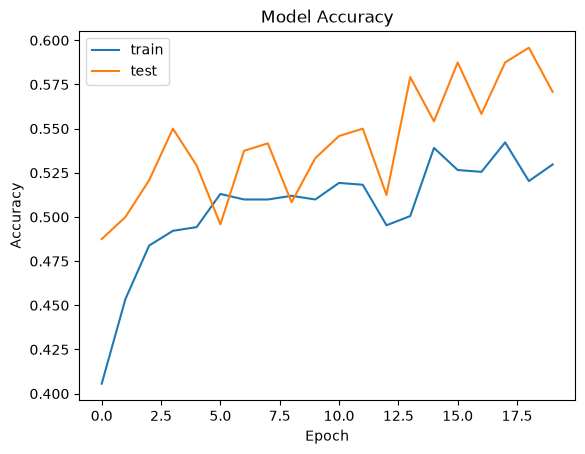

In [12]:
import matplotlib.pyplot as plt
plt.plot(model.history.history['accuracy'], label='train')
plt.plot(model.history.history['val_accuracy'], label='test')
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()
plt.show()